<a href="https://colab.research.google.com/github/YYChang34/Feedforward-Neural-Network-for-Regression/blob/main/Feedforward_Neural_Network_for_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 : Feedforward Neural Network for Regression

# Loading and preprocessing the dataset.

**選擇使用RobustScaler基於中位數和四分位數的feature scaling方式，可以有效減少極端值的影響。**


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Training data shape: (16512, 8), Training labels shape: (16512,)
Test data shape: (4128, 8), Test labels shape: (4128,)


# Outlier Detection and Handling

**使用完RobustScaler後能將資料的中心和範圍更聚焦於主要資料區間，使資料分布更接近常態分布，因此使用Z-score更適合來偵測異常值。**

**當Z-score絕對值大於3的資料可以視為異常值，因為它們與縮放後的數據分布仍有顯著差異，而當發現異常值後就會將該值移除掉。**


In [ ]:
import numpy as np

from scipy import stats
z_scores = np.abs(stats.zscore(X_train))
outliers = np.where(z_scores > 3)

X_train_cleaned = np.delete(X_train, outliers, axis=0)
y_train_cleaned = np.delete(y_train, outliers, axis=0)

print(f"Training data shape after cleaned: {X_train_cleaned.shape}, Training labels shape after cleaned: {y_train_cleaned.shape}")


Training data shape after cleaned: (15833, 8), Training labels shape after cleaned: (15833,)


# Feature Selection

**使用RFE和LinearRegression作為Feature Selection的原因在於，透過LinearRegression模型來評估各個特徵對目標變量的影響力，而RFE會從所有特徵開始逐步移除影響較小的特徵，並重複這個過程直到保留預設數量的特徵，這樣能夠自動篩選出對模型訓練最有價值的特徵。**

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()
selector = RFE(model, n_features_to_select=5)
selector = selector.fit(X_train_cleaned, y_train_cleaned)

selected_features = selector.support_
X_train_selected = X_train_cleaned[:, selected_features]
X_test_selected = X_test[:, selected_features]

print(f"Training data shape after selected: {X_train_selected.shape}, Testing data shape after selected: {X_test_selected.shape}")


Training data shape after selected: (15833, 5), Testing data shape after selected: (4128, 5)


# Feedforward Neural Network Architecture

**設計此模型架構主要有以下幾個原因：**

**1. 它具有多層的全連接層，可以逐層提取數據中隱含的特徵和模式，並且這些層的神經元數量逐步減少，有助於模型在學習更高維特徵後逐步專注於更具體的特徵表示，同時減少過多參數導致的計算量和過擬合風險。**

**2. 使用LeakyReLU而不使用ReLU原因在於，使用LeakyReLU能夠減少`死神經元問題`，使得模型在負值範圍內仍保持一定的梯度更新，有助於穩定訓練。**

**3. 使用Adam Optimizer是因爲自適應學習率的特性能夠加速收斂並在多數情況下取得良好的性能表現。**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(128, input_shape=(X_train_selected.shape[1],)),
    LeakyReLU(alpha=0.1),
    Dense(64),
    LeakyReLU(alpha=0.1),
    Dense(32),
    LeakyReLU(alpha=0.1),
    Dense(16),
    LeakyReLU(alpha=0.1),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
model.summary()


history = model.fit(X_train_selected, y_train_cleaned, validation_split=0.2, epochs=50, batch_size=16)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.9720 - val_loss: 0.4111
Epoch 2/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3549 - val_loss: 0.3905
Epoch 3/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3683 - val_loss: 0.3794
Epoch 4/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3430 - val_loss: 0.3810
Epoch 5/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3274 - val_loss: 0.3367
Epoch 6/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3134 - val_loss: 0.3395
Epoch 7/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3126 - val_loss: 0.3339
Epoch 8/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3149 - val_loss: 0.3493
Epoch 9/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3190 - val_loss: 0.3212
Epoch 10/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2983 - val_loss: 0.3626
Epoch 11/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2936 - val_loss: 0.3270
Epoch 12/50
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

# Training and validation curves plotted over epochs

**透過圖形可以發現Training Loss持續下降，代表模型在訓練集上逐步收斂，並且也代表模型能學習到訓練數據的特徵，但Validation Loss雖然整體呈現下降趨勢，卻在多個epoch中波動較大，代表在generation時不太穩定，可能需要進一步調整正則化或學習率來提升驗證表現的穩定性。**

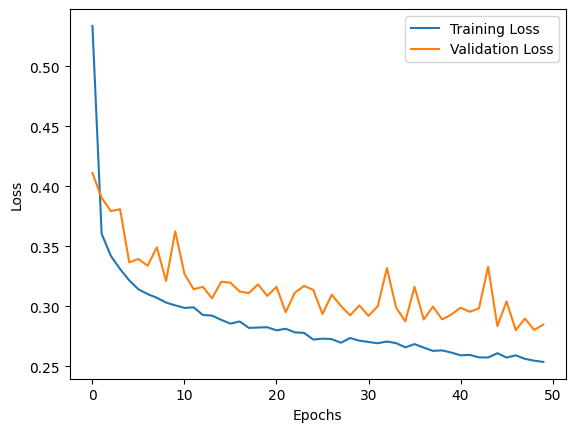

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Hyperparameter Tuning

**首先將模型架構以及Hyperparameter空間都已經定義好了，之後使用Random Search自動測試多組Hyperparameter組合，以識別最佳的Hyperparameter組合。**

**最終的Hyperparameter組合為：**

**'units4': 16, 'units3': 32, 'units2': 64, 'units1': 128, 'learning_rate': 0.0001, 'init': 'glorot_uniform', 'epochs': 150, 'batch_size': 64, 'alpha': 0.01**




In [ ]:
!pip install scikeras

In [ ]:
import scikeras
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasRegressor
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LeakyReLU, Dense
from tensorflow.keras.models import Sequential

def create_model(optimizer='adam', learning_rate=0.001, init='glorot_uniform', units1=128, units2=64, units3=32, units4=16, alpha=0.1):
    model = Sequential()
    model.add(Dense(units1, input_dim=X_train_selected.shape[1], kernel_initializer=init))
    model.add(LeakyReLU(alpha=alpha))
    model.add(Dense(units2, kernel_initializer=init))
    model.add(LeakyReLU(alpha=alpha))
    model.add(Dense(units3, kernel_initializer=init))
    model.add(LeakyReLU(alpha=alpha))
    model.add(Dense(units4, kernel_initializer=init))
    model.add(LeakyReLU(alpha=alpha))
    model.add(Dense(1))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(loss='mean_squared_error', optimizer=optimizer)
    return model

model = KerasRegressor(build_fn=create_model, verbose=0, optimizer='adam', learning_rate=0.001, init='glorot_uniform',
                       units1=128, units2=64, units3=32, units4=16, alpha=0.1)

param_dist = {
    'batch_size': [16, 32, 64, 128],
    'epochs': [50, 100, 150],
    'learning_rate': [0.01, 0.001, 0.0001],
    'init': ['glorot_uniform', 'he_uniform'],
    'units1': [32, 64, 128],
    'units2': [16, 32, 64],
    'units3': [8, 16, 32],
    'units4': [1, 8, 16],
    'alpha': [0.01, 0.1, 0.2]
}

random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=10, cv=3, n_jobs=-1)
random_search_result = random_search.fit(X_train_selected, y_train_cleaned)

print("Best Parameters Found:", random_search_result.best_params_)


/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Best Parameters Found: {'units4': 16, 'units3': 32, 'units2': 64, 'units1': 128, 'learning_rate': 0.0001, 'init': 'glorot_uniform', 'epochs': 150, 'batch_size': 64, 'alpha': 0.01}


# Regularization Techniques

**透過下方的圖形可以得知，模型經過調整Hyperparameter以及正則化之後，Training Loss和Validation Loss都在隨著epoch數增加而穩定下降，並且在接近150個epoch時接近平穩，代表模型已經收斂，並且了兩者之間的差距很小，兩條曲線趨於平行，這也代表模型的表現穩定，沒有明顯的過擬合問題。**

**以下是在講解使用多種正則化方式是如何影響模型效能：**

**1.   Dropout層：在每個Dense層後添加Dropout(0.2)，可以隨機禁用部分神經元，降低過擬合風險以此讓模型更加穩定。**

**2.   L2正則化：在每個Dense層中加入kernel_regularizer=regularizers.l2(0.001)，以懲罰較大的權重來讓模型能更加平滑。**

**3.   Early Stopping：透過EarlyStopping監控Validation Loss，當模型在15個epoch中未能取得更好結果時自動停止訓練，並恢復到最佳權重。**





In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(128, input_shape=(X_train_selected.shape[1],), kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.01),
    Dropout(0.2),

    Dense(64, kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.01),
    Dropout(0.2),

    Dense(32, kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.01),
    Dropout(0.2),

    Dense(16, kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.01),
    Dropout(0.2),

    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error')

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train_selected, y_train_cleaned, validation_split=0.2, epochs=150, batch_size=64, callbacks=[early_stopping])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 4.5218 - val_loss: 1.9978
Epoch 2/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8826 - val_loss: 0.9675
Epoch 3/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3713 - val_loss: 0.8040
Epoch 4/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2188 - val_loss: 0.7544
Epoch 5/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1212 - val_loss: 0.6871
Epoch 6/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0344 - val_loss: 0.6564
Epoch 7/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9727 - val_loss: 0.6407
Epoch 8/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9239 - val_loss: 0.6145
Epoch 9/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8956 - val_loss: 0.5953
Epoch 10/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8628 - val_loss: 0.5866
Epoch 11/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.8688 - val_loss: 0.5824
Epoch 12/150
198/198 ━━━━━━━━━━━━━━━━━━━━

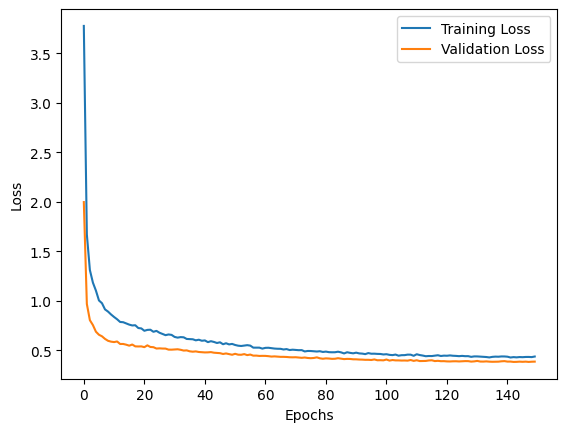

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Adaptive Learning Rate

**根據三種Optimizer（Adam、RMSprop 和 Adagrad）在模型上的Loss圖，可以得出以下分析：**

**1. Adam的`Training Loss`和`Validation Loss`都下降迅速，並在較短時間內收斂到較低的水平，因此表現非常穩定，是三者中收斂效果最好的Optimizer。**

**2. RMSprop也表現出快速的下降趨勢，並且與Adam相比在前幾個epoch中的收斂速度稍快，可以得知RMSprop與Adam效果接近，但是從穩定性和最終Loss來看，Adam略勝一籌。**

**3. Adagrad的`Training Loss`和`Validation Loss`均下降得較慢，並且由於Adagrad的學習率會隨著訓練逐漸降低，所以在接近後期時Loss下降趨緩，最後表現也不如Adam和RMSprop。**

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, RMSprop, Adagrad
from tensorflow.keras.callbacks import EarlyStopping

def train_model(optimizer):
    model = Sequential([
        Dense(128, input_shape=(X_train_selected.shape[1],), kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
        LeakyReLU(alpha=0.01),
        Dropout(0.2),

        Dense(64, kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
        LeakyReLU(alpha=0.01),
        Dropout(0.2),

        Dense(32, kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
        LeakyReLU(alpha=0.01),
        Dropout(0.2),

        Dense(16, kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
        LeakyReLU(alpha=0.01),
        Dropout(0.2),

        Dense(1)
    ])

    model.compile(optimizer=optimizer, loss='mean_squared_error')
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = model.fit(X_train_selected, y_train_cleaned, validation_split=0.2, epochs=150, batch_size=64, callbacks=[early_stopping])
    return history

history_adam = train_model(Adam(learning_rate=0.0001))
history_rmsprop = train_model(RMSprop(learning_rate=0.0001))
history_adagrad = train_model(Adagrad(learning_rate=0.0001))


Epoch 1/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 4.7955 - val_loss: 2.3276
Epoch 2/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.9684 - val_loss: 0.9558
Epoch 3/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3699 - val_loss: 0.7985
Epoch 4/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2332 - val_loss: 0.7684
Epoch 5/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1073 - val_loss: 0.7068
Epoch 6/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0114 - val_loss: 0.6716
Epoch 7/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9762 - val_loss: 0.6472
Epoch 8/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9259 - val_loss: 0.6177
Epoch 9/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9130 - val_loss: 0.6123
Epoch 10/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8770 - val_loss: 0.5962
Epoch 11/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8201 - val_loss: 0.5869
Epoch 12/150
198/198 ━━━━━━━━━━━━━━━━━━━━

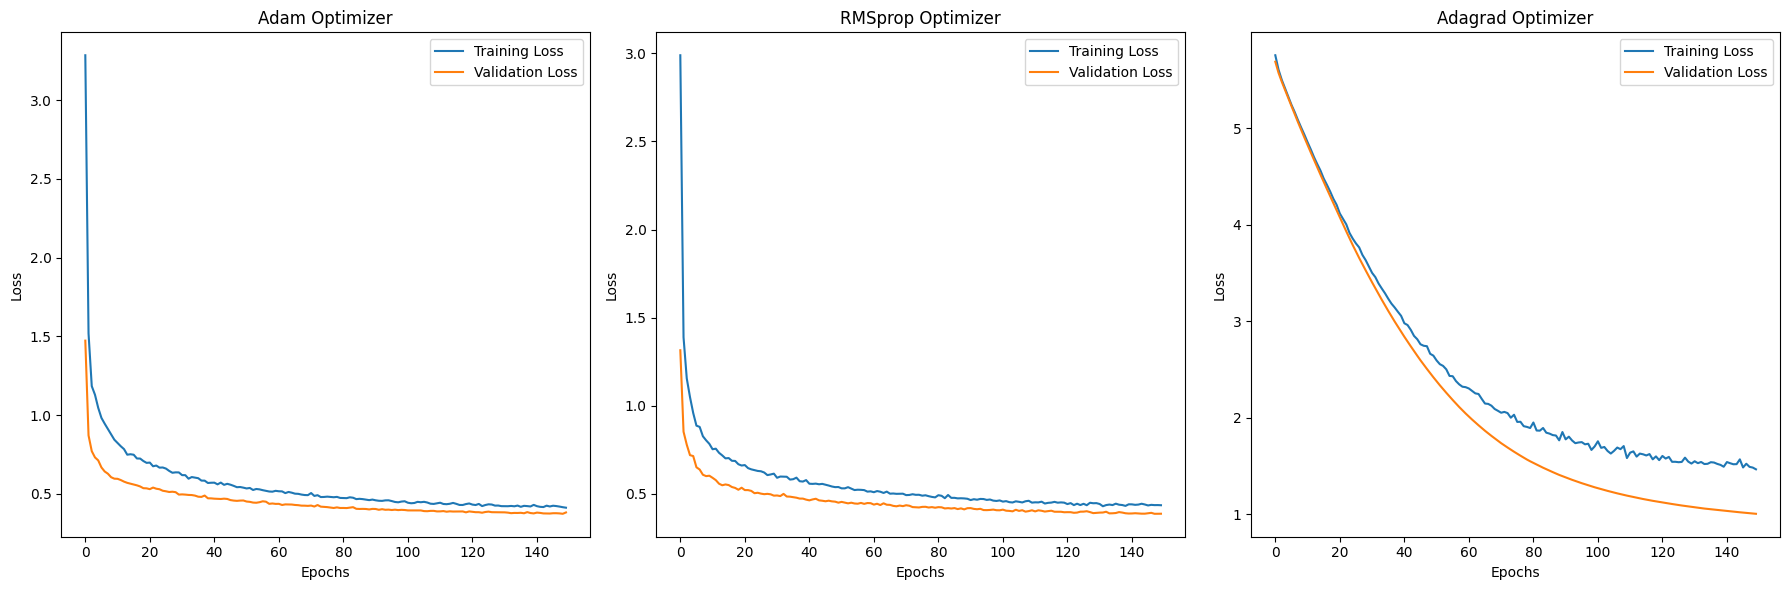

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

# Adam
plt.subplot(1, 3, 1)
plt.plot(history_adam.history['loss'], label='Training Loss')
plt.plot(history_adam.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Adam Optimizer')
plt.legend()

# RMSprop
plt.subplot(1, 3, 2)
plt.plot(history_rmsprop.history['loss'], label='Training Loss')
plt.plot(history_rmsprop.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('RMSprop Optimizer')
plt.legend()

# Adagrad
plt.subplot(1, 3, 3)
plt.plot(history_adagrad.history['loss'], label='Training Loss')
plt.plot(history_adagrad.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Adagrad Optimizer')
plt.legend()

plt.tight_layout()
plt.show()


# Evaluation metrics on the test set


In [ ]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error on test set: {mse}')


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Squared Error on test set: 0.3574869642856026


# A Brief Report

對於整體模型進行總結，可以分成：
1. 模型設計：模型採用多層全連接層逐步提取數據特徵，並通過逐層減少神經元數量來專注於更具體的特徵表示，降低計算量和過擬合風險；使用 LeakyReLU 激活函數避免死神經元問題，保持梯度更新以穩定訓練；選擇 Adam 優化器則因其自適應學習率特性，能有效加速收斂並提供良好性能；使用Dropout層可以隨機禁用部分神經元，來降低過擬合風險以此讓模型更加穩定；使用L2正則化可以懲罰較大的權重來讓模型能更加平滑；透過EarlyStopping監控Validation Loss，當模型在15個epoch中未能取得更好結果時自動停止訓練，並恢復到最佳權重，以此來防止過擬合事情發生。
2. Hyperparameter選擇：透過使用Random Search自動找出適合該模型的Hyperparameter，並效果解釋如下：

*   隱藏層結構（128、64、32、16）：這種設計可以增強模型的特徵提取能力，並降低參數量和過擬合風險。
*   Dropout(0.2)：隨機禁用20%的神經元，進一步減少過擬合風險。
*   Adam（learning_rate=0.0001）:學習率設置為0.0001，較小的學習率能使模型穩定收斂，避免因為過大學習率而導致的損失波動。
*   Early Stopping（patience=15）：允許模型在15個epoch內無明顯改進時提前停止訓練，避免不必要的計算並保存最佳權重。
*   Epochs=150：整個訓練數據上訓練最多150次，並且搭配Early Stopping機制，模型可能會在達到最佳驗證損失後提早停止，因此設置更高的epoch數量為模型提供充足的訓練機會，但不會因過多迭代而浪費計算資源。
*   Batch size=64：使用較小的batch size可能使模型收斂得更快，但可能會增加損失的波動性；而使用更大的batch size則可能需要更大的內存，並且更新速度較慢。因此batch size=64能在穩定梯度更新的同時有效利用內存資源，使模型更快速地收斂。
3. Learning curve：模型經過調整Hyperparameter以及正則化之後，Training Loss和Validation Loss都在隨著epoch數增加而穩定下降，並且在接近150個epoch時接近平穩，代表模型已經收斂，並且了兩者之間的差距很小，兩條曲線趨於平行，這也代表模型的表現穩定，沒有明顯的過擬合問題。







# Task 2: Transform the Regression Task into a Classification Problem (30%)

# Step 1
先將資料進行預處理，其中包括：
1. 劃分training data、test data
2. feature scaling(RobustScaler)
3. Z-score(Outlier Detection)
4. feature selection


In [ ]:
import numpy as np
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# feature scaling
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Z-score
z_scores = np.abs(stats.zscore(X_train))
outliers = np.where(z_scores > 3)
X_train_cleaned = np.delete(X_train, outliers, axis=0)
y_train_cleaned = np.delete(y_train, outliers, axis=0)

# feature selection
model = LinearRegression()
selector = RFE(model, n_features_to_select=5)
selector = selector.fit(X_train_cleaned, y_train_cleaned)

selected_features = selector.support_
X_train_selected = X_train_cleaned[:, selected_features]
X_test_selected = X_test[:, selected_features]

print(f"Training data shape after selected: {X_train_selected.shape}, Testing data shape after selected: {X_test_selected.shape}")

Training data shape after selected: (15833, 5), Testing data shape after selected: (4128, 5)


# Step 2
將房價分為“低”、“中”、“高”三個種類，並使用資料的百分位數進行分類：

1. Low：小於房價的 33% 百分位數。
2. Medium：介於 33% 百分位數和 66% 百分位數之間。
3. High：高於房價的 66% 百分位數。

這樣分類的原因是基於房價的分布，以保證每個類別的樣本數量相對均衡，這有助於提升並發現模型在每個類別上的學習效果。

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

low_threshold = np.percentile(y_train_cleaned, 33)
high_threshold = np.percentile(y_train_cleaned, 66)

def categorize_price(value):
    if value < low_threshold:
        return 0  # Low
    elif value < high_threshold:
        return 1  # Medium
    else:
        return 2  # High

y_train_classified = np.array([categorize_price(val) for val in y_train_cleaned])
y_test_classified = np.array([categorize_price(val) for val in y_test])


# Step 3
設計一個多層神經網絡進行分類，並將最後一層設置為三個神經元來對應三個類別，使用softmax輸出每個類別的概率。Loss函數使用sparse_categorical_crossentropy以適應多類別分類任務。

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(128, input_shape=(X_train_selected.shape[1],), kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.01),
    Dropout(0.2),

    Dense(64, kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.01),
    Dropout(0.2),

    Dense(32, kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.01),
    Dropout(0.2),

    Dense(16, kernel_initializer='glorot_uniform', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.01),
    Dropout(0.2),

    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train_selected, y_train_classified, validation_split=0.2, epochs=150, batch_size=64, callbacks=[early_stopping])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4085 - loss: 1.2311 - val_accuracy: 0.5564 - val_loss: 1.1567
Epoch 2/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5334 - loss: 1.1510 - val_accuracy: 0.6261 - val_loss: 1.0645
Epoch 3/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6018 - loss: 1.0677 - val_accuracy: 0.6495 - val_loss: 0.9590
Epoch 4/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6309 - loss: 0.9889 - val_accuracy: 0.6653 - val_loss: 0.8892
Epoch 5/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6346 - loss: 0.9394 - val_accuracy: 0.6710 - val_loss: 0.8553
Epoch 6/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6543 - loss: 0.9087 - val_accuracy: 0.6763 - val_loss: 0.8368
Epoch 7/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6636 - loss: 0.8915 - val_accuracy: 0.6833 - val_loss: 0.8224
Epoch 8/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6614 - loss: 0.8835 - val_accu

# Step 4
產生結果報告，其中包括：
1. 準確度
2. 分類結果報告
3. 混淆矩陣

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

y_pred_proba = model.predict(X_test_selected)
y_pred = np.argmax(y_pred_proba, axis=1)

# accuracy
accuracy = accuracy_score(y_test_classified, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Classification Report (precision, recall, f1-score, support)
print("\nClassification Report:")
print(classification_report(y_test_classified, y_pred, target_names=["Low", "Medium", "High"]))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_classified, y_pred))


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 0.7691

Classification Report:
              precision    recall  f1-score   support

         Low       0.81      0.84      0.82      1350
      Medium       0.66      0.66      0.66      1349
        High       0.84      0.80      0.82      1429

    accuracy                           0.77      4128
   macro avg       0.77      0.77      0.77      4128
weighted avg       0.77      0.77      0.77      4128


Confusion Matrix:
[[1134  205   11]
 [ 238  897  214]
 [  31  254 1144]]


# Step 5
提供合理的分類理由並解釋其好處：

首先，將連續的房價預測轉化為分類問題，可以讓房價分為 "Low"、"Medium" 和 "High" 三個區間，這種分類方式的意義在於，它使模型不再需要精確預測每個樣本的房價數值，而是能夠大致區分房價的範疇，這對於房價的快速評估和範圍判斷更具實際應用價值，這種劃分還能更有效的處理異常值和極端值，因為模型的關注點轉向了整體價格範疇，而不是單一的精確值。

從分類結果來看，模型在"Low"和"High"類別上表現較好，具有較高的precision值和recall值，這代表這兩個種類的特徵較為清晰，模型能夠較好的區分，而"Medium"類別的precision值和recall值相對較低，代表"Medium"與其他兩個種類存在一定重疊，因此特徵不夠明顯，這可能是由於"Medium"類別的房價分布較廣且特徵模糊造成的。

最後，將回歸問題轉化為分類問題的好處在於，模型能更直接地提供房價的範疇信息，便於決策者進行更簡化的分類判斷，並且模型gerneration的能力更強，不易受極端值影響。對於房地產市場中的需求分析或快速篩選，這樣的分類模型能更好的滿足需求，讓預測結果更具有實用價值。